In [2]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
import pingouin as pg

# 머신러닝 
from sklearn.model_selection import train_test_split

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
df = pd.read_csv('./data/merged_data.csv')

In [4]:
df2 = df.copy()

In [5]:
# review_score 컬럼 결측치 제거
print(f"제거 전 데이터 개수: {len(df2)}")
df2 = df2.dropna(subset=['review_score']).reset_index()
print(f"제거 후 데이터 개수: {len(df2)}")

제거 전 데이터 개수: 96432
제거 후 데이터 개수: 95786


In [6]:
# 파생 컬럼 생성
df2['order_purchase_timestamp'] = pd.to_datetime(df2['order_purchase_timestamp'])
df2['order_delivered_customer_date'] = pd.to_datetime(df2['order_delivered_customer_date'])
df2['order_estimated_delivery_date'] = pd.to_datetime(df2['order_estimated_delivery_date'])
df2['order_approved_at'] = pd.to_datetime(df2['order_approved_at'])
df2['order_delivered_carrier_date'] = pd.to_datetime(df2['order_delivered_carrier_date'])

# 주문 시점의 요일 정보 추가
df2['order_purchase_dayofweek'] = df2['order_purchase_timestamp'].dt.dayofweek
df2['order_purchase_dayofweek'] = df2['order_purchase_dayofweek'].map({
0: 'monday',
1: 'tuesday',
2: 'wednesday',
3: 'thursday',
4: 'friday',
5: 'saturday',
6: 'sunday'
})
# 요일 순서 정의 
weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# 데이터를 범주형(Categorical)으로 변환하여 순서 부여
# 이렇게 하면 groupby를 해도 이 순서가 유지됨
df2['order_purchase_dayofweek'] = pd.Categorical(df2['order_purchase_dayofweek'], 
                                                categories=weekday_order, 
                                                ordered=True)

# 주문 시점의 월 정보 추가
df2['order_purchase_month'] = df2['order_purchase_timestamp'].dt.month
df2['order_purchase_month'] = df2['order_purchase_month'].astype('category')
df2['order_purchase_month'] = df2['order_purchase_month'].cat.set_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
df2['order_purchase_month'] = df2['order_purchase_month'].cat.codes
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)
df2['order_purchase_month'] = df2['order_purchase_month'].map({
0: 1,
1: 2,
2: 3,
3: 4,
4: 5,
5: 6,
6: 7,
7: 8,
8: 9,
9: 10,
10: 11,
11: 12
})
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)

# 주문 시점의 연도 정보 추가
df2['order_purchase_year'] = df2['order_purchase_timestamp'].dt.year
df2['order_purchase_year'] = df2['order_purchase_year'].astype(int)

df2.info()
df2.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 95786 entries, 0 to 95785
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95786 non-null  int64         
 1   order_id                       95786 non-null  str           
 2   customer_id                    95786 non-null  str           
 3   order_purchase_timestamp       95786 non-null  datetime64[us]
 4   order_approved_at              95786 non-null  datetime64[us]
 5   order_delivered_carrier_date   95786 non-null  datetime64[us]
 6   order_delivered_customer_date  95786 non-null  datetime64[us]
 7   order_estimated_delivery_date  95786 non-null  datetime64[us]
 8   customer_unique_id             95786 non-null  str           
 9   customer_city                  95786 non-null  str           
 10  customer_state                 95786 non-null  str           
 11  total_items_count         

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",housewares,maua,SP,monday,10,2017
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,4.0,Muito boa a loja,Muito bom o produto.,perfumery,belo horizonte,SP,tuesday,7,2018
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,5.0,NaN,NaN,auto,guariba,SP,wednesday,8,2018
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,5.0,NaN,O produto foi exatamente o que eu esperava e e...,pet_shop,belo horizonte,MG,saturday,11,2017
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,5.0,NaN,NaN,stationery,mogi das cruzes,SP,tuesday,2,2018
5,5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,4.0,NaN,NaN,auto,guarulhos,SP,sunday,7,2017
6,6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,5.0,NaN,NaN,auto,atibaia,SP,tuesday,5,2017
7,7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,faxinalzinho,RS,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05,1.0,NaN,NaN,furniture_decor,sao jose do rio pardo,SP,monday,1,2017
8,8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,299905e3934e9e181bfb2e164dd4b4f8,sorocaba,SP,1,9a78fb9862b10749a117f7fc3c31f051,7c67e1448b00f6e969d365cea6b010ab,2017-08-11 12:05:32,149.99,19.77,5.0,NaN,NaN,office_furniture,itaquaquecetuba,SP,saturday,7,2017
9,9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:

In [7]:
### 승인 소요 일수 계산 (order_approved_at - order_purchase_timestamp)
df2['approved_days'] = (df2['order_approved_at'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['approved_days'] = df2['approved_days'].astype(int)

### 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df2['dispatch_days'] = (df2['order_delivered_carrier_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['dispatch_days'] = df2['dispatch_days'].astype(int)

### 실제 배송 소요 일수 계산 (order_delivered_customer_date - order_purchase_timestamp)
df2['delivery_days'] = (df2['order_delivered_customer_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['delivery_days'] = df2['delivery_days'].astype(int)

### 예상 배송 소요 일수 계산 (order_estimated_delivery_date - order_purchase_timestamp)
df2['expected_delivery_days'] = (df2['order_estimated_delivery_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['expected_delivery_days'] = df2['expected_delivery_days'].astype(int)

### 지연 일수 계산 (order_delivered_customer_date - order_estimated_delivery_date)
# 지연된 것이 양수
df2['delay_days'] = (df2['order_delivered_customer_date'] - df2['order_estimated_delivery_date']).dt.total_seconds() / 86400
df2['delay_days'] = df2['delay_days'].round(1)
df2['delay_days_int'] = df2['delay_days'].astype(int)

### 지연 여부 (0 또는 1)
df2['is_delayed'] = (df2['delay_days'] > 0).astype(int)

In [8]:
df2.head()

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",housewares,maua,SP,monday,10,2017,0,2,8,15,-7.1,-7,0
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,4.0,Muito boa a loja,Muito bom o produto.,perfumery,belo horizonte,SP,tuesday,7,2018,1,1,13,19,-5.4,-5,0
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,5.0,NaN,NaN,auto,guariba,SP,wednesday,8,2018,0,0,9,26,-17.2,-17,0
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,5.0,NaN,O produto foi exatamente o que eu esperava e e...,pet_shop,belo horizonte,MG,saturday,11,2017,0,3,13,26,-13.0,-13,0
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,5.0,NaN,NaN,stationery,mogi das cruzes,SP,tuesday,2,2018,0,0,2,12,-9.2,-9,0


In [ ]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 95786 entries, 0 to 95785
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95786 non-null  int64         
 1   order_id                       95786 non-null  str           
 2   customer_id                    95786 non-null  str           
 3   order_purchase_timestamp       95786 non-null  datetime64[us]
 4   order_approved_at              95786 non-null  datetime64[us]
 5   order_delivered_carrier_date   95786 non-null  datetime64[us]
 6   order_delivered_customer_date  95786 non-null  datetime64[us]
 7   order_estimated_delivery_date  95786 non-null  datetime64[us]
 8   customer_unique_id             95786 non-null  str           
 9   customer_city                  95786 non-null  str           
 10  customer_state                 95786 non-null  str           
 11  total_items_count         

: 

: 

In [ ]:
df2.isna().sum()

index                                0
order_id                             0
customer_id                          0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date         0
order_delivered_customer_date        0
order_estimated_delivery_date        0
customer_unique_id                   0
customer_city                        0
customer_state                       0
total_items_count                    0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
review_score                         0
review_comment_title             84598
review_comment_message           56906
product_category_name_english     1370
seller_city                          0
seller_state                         0
order_purchase_dayofweek             0
order_purchase_month                 0
order_purchase_year      

: 

: 

### 이상치 처리
#### 출고일 < 0 행 제거

In [9]:
# 이상치 처리 
data = df2[df2['dispatch_days'] < 0].copy() 
data

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_items_count,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,review_comment_title,review_comment_message,product_category_name_english,seller_city,seller_state,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
24963,25111,7c48bb55e8e4f7e56d412e9653db37bc,34ef6181341eb36c47fd601c46878f00,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,faed38109bbf7da6f035630d92a49a27,sao paulo,SP,1,9070fbe936bd54b8a72e0ffe4a6a2564,89de2d6f23e9746ff309705b23581faa,2018-07-20 18:50:22,40.0,14.58,5.0,NaN,NaN,books_technical,londrina,PR,monday,7,2018,0,-171,7,21,-14.2,-14,0
80252,80782,4021cd7611d6d9ce5ffcd24817fc374f,ac27243bffbc9c58eb62adfb58c71488,2018-08-18 11:49:40,2018-08-18 12:10:30,2018-08-14 06:22:00,2018-08-29 04:41:53,2018-08-30,216dc3bc64c10494ca97500c2a6b658f,indaiatuba,SP,1,98e55bdc6487be7b8c32b0eb689dcb8a,4a23adac87cf538689fa600d976f78b2,2018-08-23 12:10:30,135.0,8.21,4.0,NaN,NaN,furniture_decor,sao paulo,SP,saturday,8,2018,0,-4,10,11,-0.8,0,0


In [10]:
print(f"이상치 제거 전 행 수 : {len(df2)}")
df2 = df2[df2['dispatch_days'] >= 0].copy()
print(f"이상치 제거 후 행 수 : {len(df2)}")

이상치 제거 전 행 수 : 95786
이상치 제거 후 행 수 : 95784


위의 꺾은선 그래프를 보아 지연일이 3일, 6일, 9일인 지점에서 큰 변화가 일어난다고 보여져서 기준을 3일, 6일, 9일으로 잡았다

In [12]:
# delay_days를 카테고리화
def delay_days_cat(x):
    if x < 0:
         return '조기'
    elif x == 0:
         return '정시'
    elif x <= 3: 
        return '1-3일 지연'
    elif x <= 6: 
        return '4-6일 지연'
    elif x <= 9:
        return '7-9일 지연'
    else: 
        return '10일 이상 지연'

df2['delay_days_cat'] = df2['delay_days'].apply(delay_days_cat)

In [13]:
df2['delay_days_cat'].value_counts()

delay_days_cat
조기           88010
1-3일 지연       2591
10일 이상 지연     2435
4-6일 지연       1374
7-9일 지연       1199
정시             175
Name: count, dtype: int64

In [ ]:
df2.info()

<class 'pandas.DataFrame'>
Index: 95784 entries, 0 to 95785
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95784 non-null  int64         
 1   order_id                       95784 non-null  str           
 2   customer_id                    95784 non-null  str           
 3   order_purchase_timestamp       95784 non-null  datetime64[us]
 4   order_approved_at              95784 non-null  datetime64[us]
 5   order_delivered_carrier_date   95784 non-null  datetime64[us]
 6   order_delivered_customer_date  95784 non-null  datetime64[us]
 7   order_estimated_delivery_date  95784 non-null  datetime64[us]
 8   customer_unique_id             95784 non-null  str           
 9   customer_city                  95784 non-null  str           
 10  customer_state                 95784 non-null  str           
 11  total_items_count              

: 

: 

In [ ]:
df2['review_score'].value_counts()

review_score
5.000000    56682
4.000000    18859
1.000000     9304
3.000000     7911
2.000000     2912
4.500000       53
2.500000       30
3.500000       23
1.500000        8
3.333333        1
4.333333        1
Name: count, dtype: int64

: 

: 

In [14]:
cols = df2.columns
cols

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state',
       'total_items_count', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'review_comment_title',
       'review_comment_message', 'product_category_name_english',
       'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'order_purchase_year', 'approved_days',
       'dispatch_days', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'delay_days_int', 'is_delayed', 'delay_days_cat'],
      dtype='str')

In [15]:
# train / test / validation split 

X = df2[cols]
y = df2['review_score']

# Train+Valid / Test 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

### 본격적인 EDA 시작

In [16]:
print(f"test 셋 분리 전 df : {len(df2)}")
df2 = X_train_valid.copy()
print(f"test 셋 분리 후 df : {len(df2)}")

test 셋 분리 전 df : 95784
test 셋 분리 후 df : 76627


In [17]:
df2.to_csv('./data/merged_train_data.csv', index=False)

In [ ]:
df2['review_score'].value_counts()

review_score
5.000000    45287
4.000000    15084
1.000000     7519
3.000000     6346
2.000000     2291
4.500000       44
2.500000       25
3.500000       22
1.500000        8
3.333333        1
Name: count, dtype: int64

: 

: 

In [ ]:
# 1. 온타임 그룹 정의 (delay_days <= 0)
df_ontime = df2[df2['delay_days'] <= 0].copy()

# 2. 온타임 그룹 내에서 배송 소요 일수의 중앙값 산출
# 중앙값을 기준으로 하면 데이터의 치우침(Skewness)에 강건한 기준을 세울 수 있습니다.
ontime_duration_median = df_ontime['delivery_days'].median()
print(f"온타임 그룹의 배송 소요일 중앙값: {ontime_duration_median:.1f}일")

# 3. 세 세부 그룹 생성
# 그룹 1: 정시에 도착했고, 절대적 속도도 빠른 경우
ontime_fast = df_ontime[df_ontime['delivery_days'] <= ontime_duration_median]['review_score']

# 그룹 2: 정시에 도착했으나, 절대적 속도는 느린 경우 (약속은 지켰지만 오래 기다림)
ontime_slow = df_ontime[df_ontime['delivery_days'] > ontime_duration_median]['review_score']

# 그룹 3: 약속된 날짜보다 늦게 도착한 경우 (지연)
delayed_group = df2[df2['delay_days'] > 0]['review_score']

# 4. 결과 출력
print("-" * 30)
print(f"1. 정시-신속 그룹 평균 점수: {ontime_fast.mean():.2f} (n={len(ontime_fast)})")
print(f"2. 정시-저속 그룹 평균 점수: {ontime_slow.mean():.2f} (n={len(ontime_slow)})")
print(f"3. 배송 지연 그룹 평균 점수: {delayed_group.mean():.2f} (n={len(delayed_group)})")

# 5. 통계적 유의성 확인 (Kruskal-Wallis 검정: 세 집단 이상의 평균 차이 확인)
from scipy.stats import kruskal
stat, p_val = kruskal(ontime_fast, ontime_slow, delayed_group)
print(f"\n세 집단 간 차이 유의성 (p-value): {p_val:.4e}")

온타임 그룹의 배송 소요일 중앙값: 9.0일
------------------------------
1. 정시-신속 그룹 평균 점수: 4.39 (n=36665)
2. 정시-저속 그룹 평균 점수: 4.19 (n=33877)
3. 배송 지연 그룹 평균 점수: 2.54 (n=6085)

세 집단 간 차이 유의성 (p-value): 0.0000e+00


: 

: 

In [ ]:
df2.columns

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state',
       'total_items_count', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'review_comment_title',
       'review_comment_message', 'product_category_name_english',
       'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'order_purchase_year', 'approved_days',
       'dispatch_days', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'delay_days_int', 'is_delayed', 'delay_days_cat',
       'dispatch_speed', 'carrier_days'],
      dtype='str')

: 

: 

In [76]:
category_group_map = {

    # 1. Home & Living
    'bed_bath_table': 'home_living',
    'furniture_decor': 'home_living',
    'office_furniture': 'home_living',
    'furniture_living_room': 'home_living',
    'furniture_bedroom': 'home_living',
    'furniture_mattress_and_upholstery': 'home_living',
    'housewares': 'home_living',
    'home_confort': 'home_living',
    'home_comfort_2': 'home_living',
    'kitchen_dining_laundry_garden_furniture': 'home_living',
    'la_cuisine': 'home_living',
    'home_appliances': 'home_living',
    'home_appliances_2': 'home_living',
    'small_appliances': 'home_living',
    'small_appliances_home_oven_and_coffee': 'home_living',
    'air_conditioning': 'home_living',

    # 2. Personal Care & Fashion
    'health_beauty': 'personalcare_fashion',
    'perfumery': 'personalcare_fashion',
    'diapers_and_hygiene': 'personalcare_fashion',
    'watches_gifts': 'personalcare_fashion',
    'fashion_bags_accessories': 'personalcare_fashion',
    'luggage_accessories': 'personalcare_fashion',
    'fashion_shoes': 'personalcare_fashion',
    'fashion_underwear_beach': 'personalcare_fashion',
    'fashion_male_clothing': 'personalcare_fashion',
    'fashio_female_clothing': 'personalcare_fashion',
    'fashion_sport': 'personalcare_fashion',
    'fashion_childrens_clothes': 'personalcare_fashion',

    # 3. Electronics & Tech
    'computers_accessories': 'electronics_tech',
    'computers': 'electronics_tech',
    'tablets_printing_image': 'electronics_tech',
    'telephony': 'electronics_tech',
    'fixed_telephony': 'electronics_tech',
    'electronics': 'electronics_tech',
    'audio': 'electronics_tech',
    'cine_photo': 'electronics_tech',

    # 4. Hobbies, Leisure & Kids
    'toys': 'hobbies_leisure_kids',
    'baby': 'hobbies_leisure_kids',
    'sports_leisure': 'hobbies_leisure_kids',
    'books_general_interest': 'hobbies_leisure_kids',
    'books_technical': 'hobbies_leisure_kids',
    'books_imported': 'hobbies_leisure_kids',
    'consoles_games': 'hobbies_leisure_kids',
    'dvds_blu_ray': 'hobbies_leisure_kids',
    'music': 'hobbies_leisure_kids',
    'cds_dvds_musicals': 'hobbies_leisure_kids',
    'art': 'hobbies_leisure_kids',
    'arts_and_craftmanship': 'hobbies_leisure_kids',
    'cool_stuff': 'hobbies_leisure_kids',
    'party_supplies': 'hobbies_leisure_kids',
    'christmas_supplies': 'hobbies_leisure_kids',

    # 5. DIY, Garden & Industry
    'garden_tools': 'diy_garden_industry',
    'costruction_tools_garden': 'diy_garden_industry',
    'flowers': 'diy_garden_industry',
    'agro_industry_and_commerce': 'diy_garden_industry',
    'construction_tools_construction': 'diy_garden_industry',
    'home_construction': 'diy_garden_industry',
    'construction_tools_lights': 'diy_garden_industry',
    'construction_tools_safety': 'diy_garden_industry',
    'costruction_tools_tools': 'diy_garden_industry',
    'signaling_and_security': 'diy_garden_industry',
    'industry_commerce_and_business': 'diy_garden_industry',
    'stationery': 'diy_garden_industry',

    # 6. Automotive & Food
    'auto': 'automotivie_food',
    'food': 'automotivie_food',
    'food_drink': 'automotivie_food',
    'drinks': 'automotivie_food',
    'pet_shop': 'automotivie_food',
    'market_place': 'automotivie_food',
    'security_and_services': 'automotivie_food'
}

# 새 카테고리 그룹 컬럼 생성
df2['category_group'] = df2['product_category_name_english'].map(category_group_map)

In [77]:
df2['category_group'].value_counts()

category_group
home_living             20106
personalcare_fashion    16345
hobbies_leisure_kids    15770
electronics_tech        11090
diy_garden_industry      6450
automotivie_food         5331
Name: count, dtype: int64

In [78]:

# 판매자 state별 통계 계산
seller_state_stats = df2.groupby('seller_state').agg(
    total_orders=('total_items_count', 'sum'),
    delay_rate=('is_delayed', lambda x: x.mean() * 100),    # 지연율(%)
    avg_review_score=('review_score', 'mean')               # 평균 리뷰 점수
).reset_index()

In [79]:
seller_state_stats.head(20)

,seller_state,total_orders,delay_rate,avg_review_score
0,AM,3,66.666667,2.333333
1,BA,503,5.504587,4.192661
2,CE,58,14.545455,4.272727
3,DF,705,6.356589,4.083721
4,ES,283,4.958678,4.140496
5,GO,417,4.359673,4.386921
6,MA,323,22.857143,4.022222
7,MG,6861,5.574684,4.231841
8,MS,39,7.894737,4.657895
9,MT,116,4.545455,4.209091


In [ ]:
# 판매자 state 별 카테고리

seller_state_cat = df2.groupby(['seller_state','category_group'])['total_items_count'].sum().unstack(fill_value=0)

seller_state_cat.head(10)

category_group,automotivie_food,diy_garden_industry,electronics_tech,hobbies_leisure_kids,home_living,personalcare_fashion
seller_state,,,,,,
AM,0,0,3,0,0,0
BA,31,1,414,30,1,26
CE,23,0,0,10,7,18
DF,7,65,250,111,98,167
ES,3,209,12,21,22,8
GO,39,17,34,183,74,62
MA,0,0,0,0,0,323
MG,616,837,1296,1149,1602,1184
MS,15,0,0,7,1,16


In [32]:
# 판매자 state별 카테고리 비율
seller_state_cat_ratio = seller_state_cat.div(seller_state_cat.sum(axis=1), axis=0).round(4) *100

seller_state_cat_ratio.head()

category_group,automotivie_food,diy_garden_industry,electronics_tech,hobbies_leisure_kids,home_living,personalcare_fashion
seller_state,,,,,,
AM,0.00,0.00,100.00,0.00,0.00,0.00
BA,6.16,0.20,82.31,5.96,0.20,5.17
CE,39.66,0.00,0.00,17.24,12.07,31.03
DF,1.00,9.31,35.82,15.90,14.04,23.93
ES,1.09,76.00,4.36,7.64,8.00,2.91


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

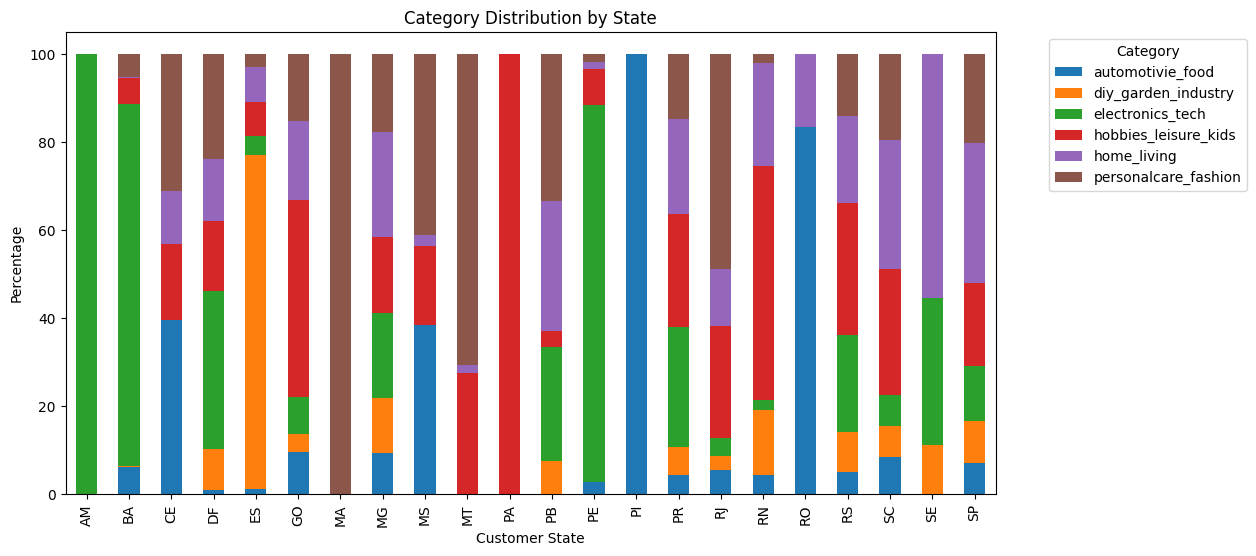

In [33]:
# seller_state_cat_ratio 시각화

seller_state_cat_ratio.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Category Distribution by State")
plt.xlabel("Customer State")
plt.ylabel("Percentage")
plt.legend(title="Category", bbox_to_anchor=(1.05,1))
plt.show()

In [47]:
# 상위 10개 state만

top_states = seller_state_cat.sum(axis=1).sort_values(ascending=False).head(10).index

top_state_ratio = seller_state_cat_ratio.loc[top_states].round(2)

top_state_ratio

category_group,automotivie_food,diy_garden_industry,electronics_tech,hobbies_leisure_kids,home_living,personalcare_fashion
seller_state,,,,,,
SP,7.14,9.34,12.57,18.89,31.87,20.19
MG,9.22,12.52,19.39,17.19,23.97,17.71
PR,4.22,6.55,27.17,25.71,21.56,14.78
RJ,5.37,3.26,4.12,25.35,13.11,48.79
SC,8.38,7.02,7.02,28.77,29.36,19.45
RS,5.02,9.09,22.12,29.95,19.67,14.17
DF,1.00,9.31,35.82,15.90,14.04,23.93
BA,6.16,0.20,82.31,5.96,0.20,5.17
GO,9.54,4.16,8.31,44.74,18.09,15.16


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

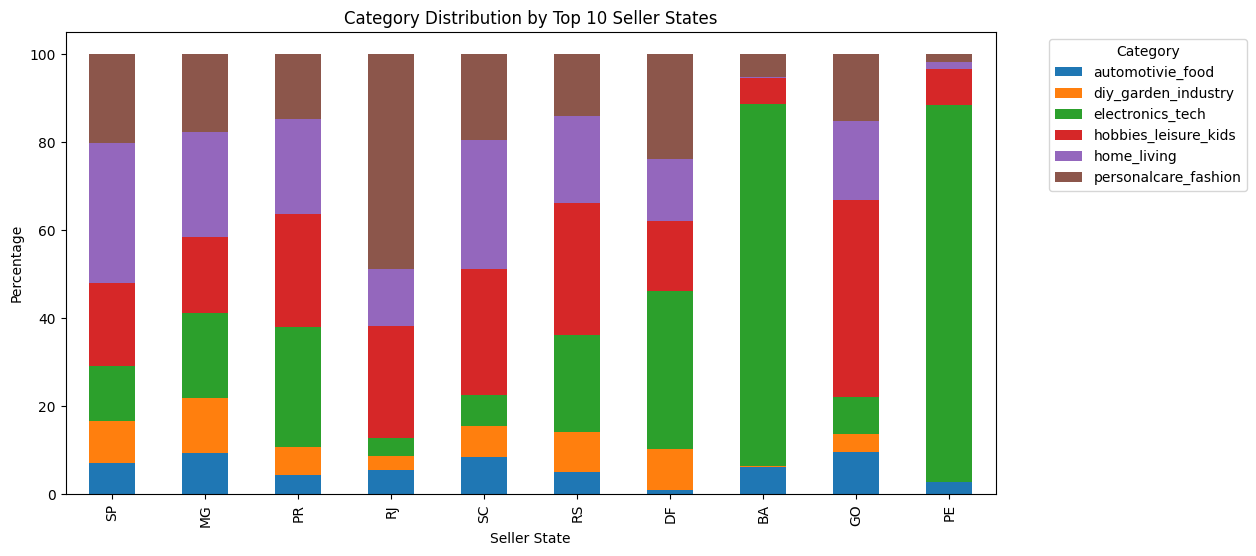

In [48]:
top_state_ratio.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Category Distribution by Top 10 Seller States')
plt.xlabel('Seller State')
plt.ylabel('Percentage')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

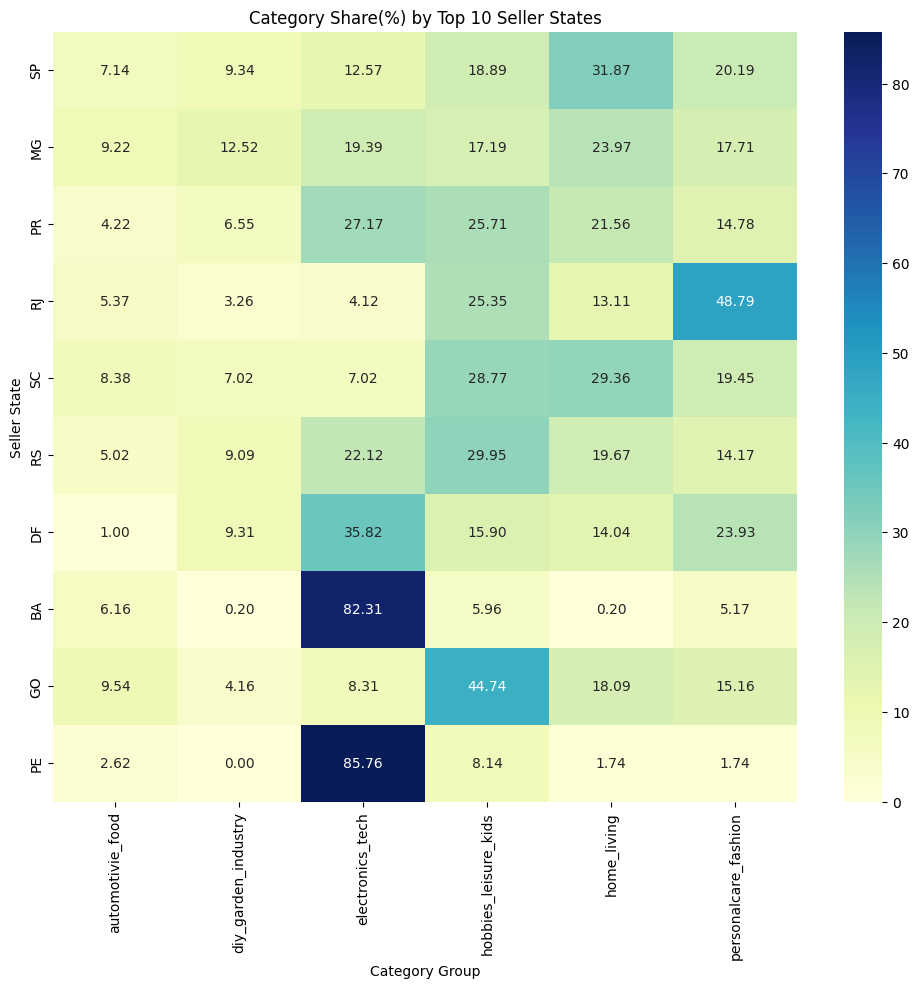

In [51]:
plt.figure(figsize=(12,10))

sns.heatmap(
    top_state_ratio,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Category Share(%) by Top 10 Seller States')
plt.xlabel('Category Group')
plt.ylabel('Seller State')
plt.show()

### 지연률이 높은 지역은 특정 카테고리 때문인가?
state x category x delay_rate

In [87]:
# 지역별 카테고리별 지연률 
state_cat_summary = df2.groupby(['seller_state','category_group']).agg(
    delay_rate=('is_delayed', lambda x: x.mean()*100),
    orders=('total_items_count', 'sum')
).reset_index()

In [ ]:
# seller_state별 판매량 정렬
state_order = state_cat_summary.groupby('seller_state')['orders'].sum().sort_values(ascending=False)

state_order.head()

seller_state
SP    61195
MG     6684
PR     6683
RJ     3593
SC     3007
Name: orders, dtype: int64

In [99]:
state_cat_delay = state_cat_summary.set_index(['seller_state', 'category_group'])['delay_rate'].unstack()

# 판매량 순으로 재정렬
state_cat_delay = state_cat_delay.loc[state_order.index]

top7_state_cat_delay = state_cat_delay.head(7)

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

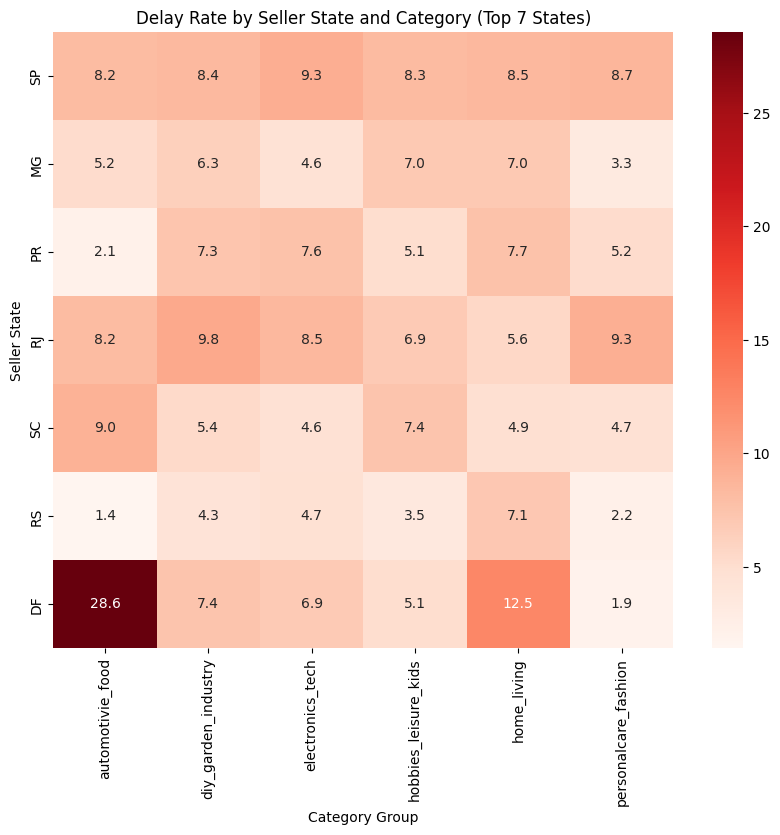

In [100]:
plt.figure(figsize=(10,8))

sns.heatmap(
    top7_state_cat_delay,
    cmap='Reds',
    annot=True,
    fmt='.1f'
)

plt.title('Delay Rate by Seller State and Category (Top 7 States)')
plt.xlabel('Category Group')
plt.ylabel('Seller State')

plt.show()